# Aproximação de Funções com MLP (Multi-Layer Perceptron)

Este exemplo demonstra como uma rede neural do tipo MLP pode ser utilizada como um **aproximador universal de funções**. De acordo com o teorema da aproximação universal, uma rede feedforward com uma única camada oculta contendo um número finito de neurônios pode aproximar funções contínuas em subconjuntos compactos do $\mathbb{R}^n$.

### O Problema
Vamos tentar aproximar a função trigonométrica **seno**:
$$y = \sin(x)$$

No intervalo de $[0, 2\pi]$. Este é um problema de regressão onde a rede deve aprender a mapear uma entrada escalar $x$ para uma saída escalar $y$.

### Bibliotecas

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### Geração de Dados

In [3]:
def gerar_dados_seno(n_amostras=1000):
    """Gera dados da função seno com um pouco de ruído."""
    X = np.linspace(0, 2 * np.pi, n_amostras).reshape(-1, 1)
    y = np.sin(X).ravel()
    # Adicionando um pequeno ruído para tornar o desafio mais real
    y += 0.1 * np.random.randn(n_amostras)
    return X, y

X, y = gerar_dados_seno()

In [4]:
# Divisão em treino e teste
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total de amostras: {len(X)}")

Total de amostras: 1000


### Configuração e Treinamento da Rede com TensorFlow

Utilizaremos o framework **TensorFlow/Keras**. Configuraremos a rede com:
- Uma camada de entrada explícita.
- Duas camadas ocultas (100 e 50 neurônios) com ativação `tanh`.
- Uma camada de saída com 1 neurônio (regressão).
- Otimizador `Adam` e função de perda `MSE` (Mean Squared Error).

In [ ]:
modelo_mlp = tf.keras.Sequential([
    tf.keras.Input(shape=(1,)),
    tf.keras.layers.Dense(100, activation='tanh'),
    tf.keras.layers.Dense(50, activation='tanh'),
    tf.keras.layers.Dense(1)
])

# Compilação
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
funcao_perda = tf.keras.losses.MeanSquaredError()
modelo_mlp.compile(optimizer=optimizer, loss=funcao_perda)

# Treinamento
historico = modelo_mlp.fit(
    X_treino, y_treino,
    epochs=200,
    batch_size=32,
    validation_split=0.1
)

### Avaliação dos Resultados

Agora vamos visualizar a performance do modelo comparando as predições com os valores reais da função seno.

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


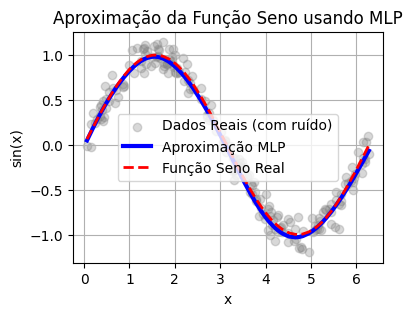

In [14]:
# Predição
y_predito = modelo_mlp.predict(X_teste).flatten()

# Visualização
indices_ordenados = np.argsort(X_teste.ravel())
X_plot = X_teste[indices_ordenados]
y_plot = y_predito[indices_ordenados]

plt.figure(figsize=(4, 3))
plt.scatter(X_teste, y_teste, color='gray', alpha=0.3, label='Dados Reais (com ruído)')
plt.plot(X_plot, y_plot, color='blue', linewidth=3, label='Aproximação MLP')
plt.plot(X_plot, np.sin(X_plot), color='red', linewidth=2, linestyle='--', label='Função Seno Real') # para comparar

plt.title('Aproximação da Função Seno usando MLP')
plt.xlabel('x')
plt.ylabel('sin(x)')
plt.legend()
plt.grid(True)
plt.show()

1. Erro Quadrático Médio (MSE): O MSE mede a média dos quadrados dos erros. Como os erros são elevados ao quadrado, essa métrica penaliza severamente erros grandes.


2. Erro Absoluto Médio (MAE): O MAE é a média da diferença absoluta entre o valor real e a previsão.

3. Coeficiente de Determinação (R²): O R² indica quanto da variação dos dados é explicada pelo modelo. Ele varia de 0 a 1 (ou 0% a 100%).

In [11]:
# Avaliação
loss = modelo_mlp.evaluate(X_teste, y_teste, verbose=0)
print(f"Erro Quadrático Médio (MSE) no Teste: {loss:.4f}")

mse = mean_squared_error(y_teste, y_predito)
mae = mean_absolute_error(y_teste, y_predito)
r2 = r2_score(y_teste, y_predito)
print(f"Erro Absoluto Médio (MAE): {mae:.4f}")
print(f"Coeficiente de Determinação (R^2): {r2:.4f}")


Erro Quadrático Médio (MSE) no Teste: 0.0110
Erro Absoluto Médio (MAE): 0.0849
Coeficiente de Determinação (R^2): 0.9789


Uma regressão com R² acima de 0.95 é considerada boa. O fato de o MSE ser quase zero e o gráfico mostrar que a linha azul (MLP) se sobrepõe à curva teórica (seno real) confirma que a rede MLP aprendeu a 'essência' da função, ignorando o ruído que adicionamos propositalmente.